# 09 - Trust-adjusted Rating and Hidden Gems (PuneBite Analyzer)

**Objective:** build a rating that does not over-reward restaurants with only a few votes, then use it to find *hidden gems*: good restaurants that few people know yet.
**Input:** `data/processed/restaurants_clean.csv` (and `data/processed/restaurants_clusters.csv` from notebook 07)
**Output:** the logic lives in `ml/scoring.py` (used by `backend/load_data.py` and the API); this notebook justifies and sanity-checks it.

**Formula** (a weighted / Bayesian average, the same idea IMDb uses for its Top 250):

`trust = v/(v+m) * R + m/(v+m) * C`

R = restaurant rating, v = its votes, C = mean rating of all rated restaurants, m = how many votes we want before trusting a restaurant's own rating as much as the overall average.

In [1]:
import os, sys, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr
from ml import scoring

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/restaurants_clean.csv")
rated = df[df["rating"].notna()].copy()
C = scoring.global_mean(df)
print(f"Rated restaurants: {len(rated)} | C (mean rating) = {C:.3f}")

Rated restaurants: 7669 | C (mean rating) = 3.436

## 1. Why we need it: ratings and votes are tied together
Restaurants with few votes sit in a narrow band near 3.0; the mean rating climbs steadily with votes (3.0 below 5 votes, 4.1 above 500), and almost every 4.0+ rating comes from a place with many votes. So a high rating from only a handful of voters is rare and should not be taken at face value: it should have to *earn* its place with votes.

           restaurants  mean   std  share_4plus
vote_band                                      
<5                 421  3.03  0.10         0.00
5-9               1230  3.10  0.14         0.00
10-19             1373  3.24  0.22         0.00
20-49             1616  3.41  0.31         0.02
50-99             1054  3.55  0.36         0.07
100-199            723  3.68  0.38         0.20
200-499            721  3.83  0.41         0.37
500+               514  4.07  0.37         0.65

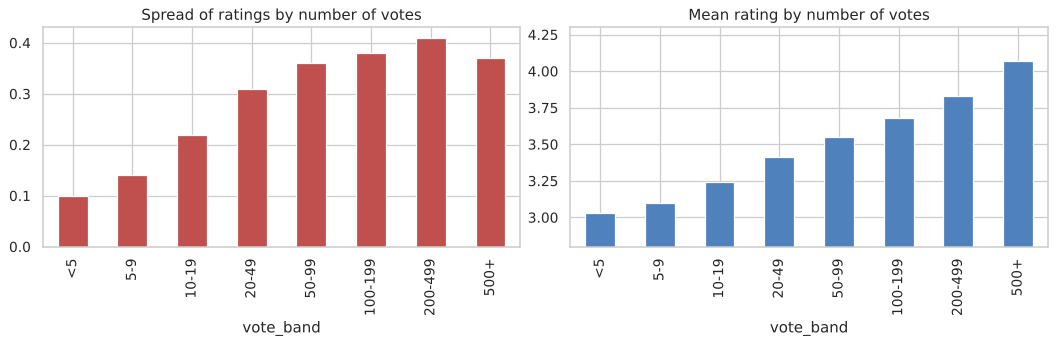

In [2]:
bins = [0, 4, 9, 19, 49, 99, 199, 499, 10**6]
labels = ["<5", "5-9", "10-19", "20-49", "50-99", "100-199", "200-499", "500+"]
rated["vote_band"] = pd.cut(rated["votes"], bins=bins, labels=labels)
band = rated.groupby("vote_band", observed=True)["rating"].agg(restaurants="size", mean="mean", std="std", share_4plus=lambda s: (s >= 4).mean()).round(2)
print(band)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
band["std"].plot(kind="bar", ax=ax[0], color="#c0504d"); ax[0].set_title("Spread of ratings by number of votes")
band["mean"].plot(kind="bar", ax=ax[1], color="#4f81bd"); ax[1].set_title("Mean rating by number of votes"); ax[1].set_ylim(2.8, 4.3)
plt.tight_layout()

## 2. Choosing m
There is no sharp natural cut-off in the table above (mean and spread keep changing up to 500 votes), so m is a judgement call. We use **m = 50**: it is the "popular" threshold already used in notebooks 02 and 03, and a restaurant with 50 votes is then judged half on its own rating and half on the average. What matters is that the *ranking* is not sensitive to this choice, which we check next.

In [3]:
rows = []
base = scoring.trust_rating(rated["rating"], rated["votes"], m=50, c=C).values
top_base = set(np.argsort(-base)[:200])
for m in (10, 25, 50, 100, 200):
    t = scoring.trust_rating(rated["rating"], rated["votes"], m=m, c=C).values
    rows.append({"m": m, "spearman_with_rating": spearmanr(t, rated["rating"])[0],
                 "spearman_with_m50": spearmanr(t, base)[0],
                 "top200_overlap_with_m50": len(top_base & set(np.argsort(-t)[:200])) / 200})
pd.DataFrame(rows).round(3)

     m  spearman_with_rating  spearman_with_m50  top200_overlap_with_m50
0   10                 0.983              0.991                    0.925
1   25                 0.968              0.999                    0.970
2   50                 0.958              1.000                    1.000
3  100                 0.946              0.998                    0.950
4  200                 0.937              0.995                    0.870

Between m = 25 and m = 100 the ranking correlates 0.998 or better with the m = 50 ranking and 95-97% of the top 200 stay the same, so the exact value is not critical.

## 3. The effect on individual restaurants
Note that 17 restaurants carry a rating but zero votes; with no evidence their trust rating is just C (3.44). They appear first in the "biggest drops" list below.

Biggest drops (high rating but few votes):
                             name              locality  rating  votes  trust_rating
                          Camios!                 Nigdi     4.3      0          3.44
                 Lehza Veg Divine                 Wakad     4.2      0          3.44
Shortcuts - Quick Meals On The Go             Hinjawadi     4.4     28          3.78
                          Yollops               Kothrud     4.6     48          4.01
               Kitchen Cornucopia Pimpri Chinchwad Area     4.3     24          3.72
               Briju's Patisserie               Bhugaon     4.3     25          3.72

Barely changed (many votes):
                     name            locality  rating  votes  trust_rating
AB's - Absolute Barbecues           Hinjawadi     4.9   7029          4.89
    Cafe Co2 Resto Lounge             Bhugaon     4.6   2578          4.58
Paasha - JW Marriott Pune Senapati Bapat Road     4.6   3291          4.58
           FC Road Social       

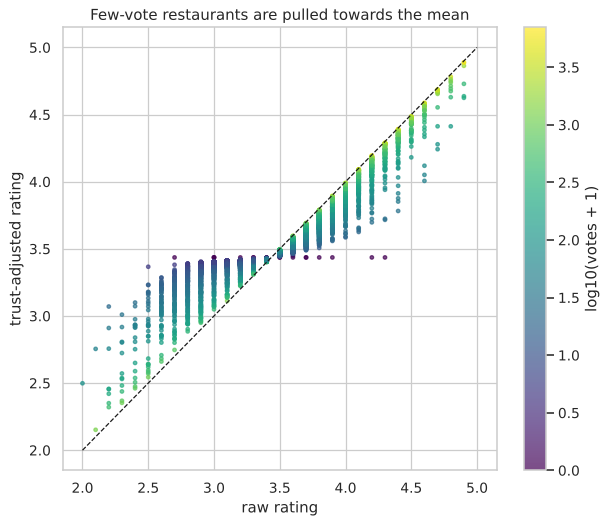

In [4]:
t = scoring.add_trust(df)
r = t[t["trust_rating"].notna()].copy()
r["shift"] = r["trust_rating"] - r["rating"]
print("Biggest drops (high rating but few votes):")
print(r.sort_values("shift").head(6)[["name", "locality", "rating", "votes", "trust_rating"]].round(2).to_string(index=False))
print()
print("Barely changed (many votes):")
print(r[r["votes"] > 2000].head(4)[["name", "locality", "rating", "votes", "trust_rating"]].round(2).to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(r["rating"], r["trust_rating"], c=np.log10(r["votes"] + 1), cmap="viridis", s=8, alpha=0.7)
ax.plot([2, 5], [2, 5], "k--", lw=1); ax.set_xlabel("raw rating"); ax.set_ylabel("trust-adjusted rating")
plt.colorbar(sc, label="log10(votes + 1)"); ax.set_title("Few-vote restaurants are pulled towards the mean")
plt.tight_layout()

## 4. Hidden gems
A hidden gem should be (1) **good for its area**: in the top 15% of its locality by trust rating, (2) **good in absolute terms**: trust rating at least 3.7, (3) **not yet famous**: 20 to 200 votes. Below 20 votes the score is mostly the prior; above 200 the place is already well known. Localities with fewer than 10 rated restaurants are skipped because "top 15% of 5 places" means nothing.

In [5]:
gems = t[t["is_hidden_gem"]].copy()
print(f"Hidden gems: {len(gems)} in {gems['locality'].nunique()} localities")
print(gems[["rating", "votes", "trust_rating", "cost_capped"]].describe().round(2).T)
print()
print("Top 10 by trust rating:")
print(gems.sort_values("trust_rating", ascending=False).head(10)[["name", "locality", "primary_type", "rating", "votes", "trust_rating"]].round(2).to_string(index=False))

Hidden gems: 231 in 61 localities
              count    mean     std    min     25%     50%     75%      max
rating        231.0    4.05    0.20    3.8    3.90    4.00    4.10     4.80
votes         231.0  130.08   43.86   24.0   91.00  136.00  168.00   200.00
trust_rating  231.0    3.87    0.14    3.7    3.77    3.82    3.94     4.41
cost_capped   231.0  568.83  434.19  100.0  300.00  400.00  600.00  2000.00

Top 10 by trust rating:
                             name      locality   primary_type  rating  votes  trust_rating
1st Story - Bar. Kitchen. Co-Work   Viman Nagar            Bar     4.7    170          4.41
                             Flax Kalyani Nagar  Casual Dining     4.8    126          4.41
                       Wings & Co   Viman Nagar    Quick Bites     4.6    188          4.36
                     Waffle World Pimple Nilakh Dessert Parlor     4.6    169          4.33
                          Chianti   Viman Nagar  Casual Dining     4.7    100          4.28
      Sha

In [6]:
# how does this differ from the naive "rating >= 4.0 and 20-150 votes" rule used as a placeholder?
naive = rated[(rated["rating"] >= 4.0) & rated["votes"].between(20, 150)]
overlap = set(naive["url"]) & set(gems["url"])
print(f"Naive rule: {len(naive)} | trust-based gems: {len(gems)} | in both: {len(overlap)}")
print("Trust-based gems that the naive rule misses (rating below 4.0, but best in their locality):", int((gems["rating"] < 4.0).sum()))
print("Naive picks the trust rule rejects:", len(set(naive['url']) - set(gems['url'])))
print()
print("Gems per locality (top 8):"); print(gems["locality"].value_counts().head(8).to_string())

Naive rule: 173 | trust-based gems: 231 | in both: 86
Trust-based gems that the naive rule misses (rating below 4.0, but best in their locality): 87
Naive picks the trust rule rejects: 87

Gems per locality (top 8):
locality
Kharadi            16
Wakad              14
Kothrud            12
Pimple Saudagar    10
Karve Nagar         9
Hinjawadi           9
Pimpri              9
Bibvewadi           8

In [7]:
# compare with the clusters from notebook 07
cl = pd.read_csv("../data/processed/restaurants_clusters.csv")
g = gems.merge(cl[["url", "cluster_name"]], on="url", how="left")
print((g["cluster_name"].fillna("(not clustered)").value_counts(normalize=True) * 100).round(1).to_string())
print()
print("Types of gems:"); print((gems["primary_type"].value_counts(normalize=True).head(5) * 100).round(1).to_string())
print("Median cost: gems Rs %d vs all rated Rs %d" % (gems["cost_capped"].median(), r["cost_capped"].median()))

cluster_name
Solid mainstream       76.6
Premium and popular    16.5
Budget everyday         6.9

Types of gems:
primary_type
Quick Bites       36.4
Casual Dining     21.2
Café               8.7
Takeaway           7.8
Dessert Parlor     6.9
Median cost: gems Rs 400 vs all rated Rs 400

## 5. Summary and findings
* **Trust rating:** `v/(v+m)*R + m/(v+m)*C` with m = 50 and C = 3.436 (mean of 7,669 rated restaurants). Restaurants with thousands of votes keep their rating (AB's Absolute Barbecues 4.9 -> 4.89); a 4.6 from 48 votes becomes 4.0.
* **m is not critical:** from m = 25 to 100 the ranking correlates at least 0.998 with m = 50 and 95-97% of the top 200 are unchanged.
* **Hidden gems:** 231 restaurants in 61 localities (top 15% of their locality by trust rating, 20-200 votes, trust >= 3.7). They average 4.05 raw rating from 130 votes; 36% are Quick Bites and 21% Casual Dining. Kharadi (16), Wakad (14) and Kothrud (12) have the most. About 77% fall in the "Solid mainstream" cluster and 17% in "Premium and popular".
* **Versus the old placeholder rule** (rating >= 4.0, 20-150 votes): only 86 of the 231 gems and 173 old picks overlap. The trust rule drops 87 picks (4.0+ ratings that are weaker than the locality's best once votes are considered) and adds 87 restaurants rated 3.8-3.9 that are the best in their area.
* **Limitations (be upfront in the viva):** (1) The prior C is the global mean, but low-vote restaurants are on average rated *lower* (about 3.0-3.2), so for them shrinkage can raise a low score; the trust rating is meant for ranking the top of the list, not for repairing weak ratings. (2) Votes measure popularity as well as reliability, and Zomato votes are not random samples. (3) Gem thresholds (top 15%, 20-200 votes, trust >= 3.7) are judgement calls; they are constants at the top of `ml/scoring.py`. (4) No location or review text, so we cannot check why a gem is good.